In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from mpl_toolkits.mplot3d import axes3d
import scipy

from scipy.io import savemat

# %matplotlib widget

(36, 36, 222)
error - nan
error - nan
error - nan


/tmp/ipykernel_13893/1340434613.py:84: RuntimeWarning: Mean of empty slice
  sim_mu = np.nanmean(sim,2)


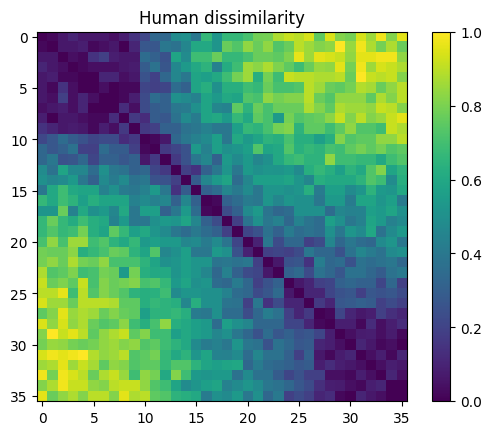

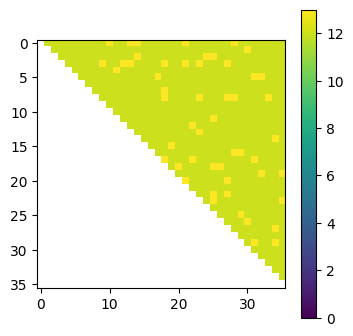

13.0


/tmp/ipykernel_13893/1340434613.py:175: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(proj[k,0],proj[k,1], c=clrs[k]/255)


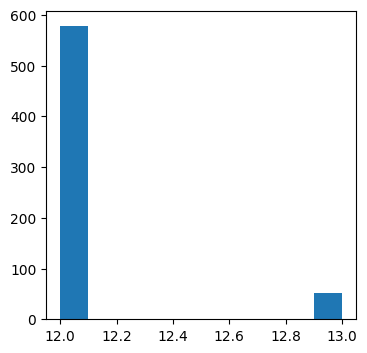

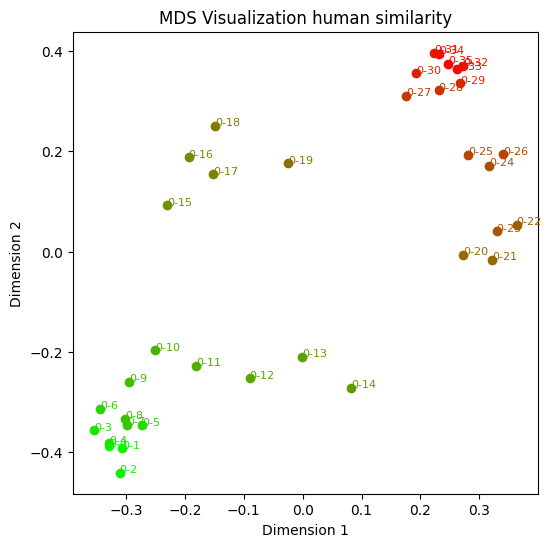

In [11]:
# ==> HUMAN SIMILARITY

# ==> parameters associated with mosaic...
reso = 36 #26 
# ==> alphas for interpolation
alphas = np.linspace(0.0,1.0,reso)
alphas = alphas[::-1]
# ==> resolution (in other dimension)
reso_v = 1
# ==> simplify... clean up these
m = reso
n = reso_v

# ==> psynet prolific similarity
dr = '/home/thomas/Desktop/MIT-Experiments/prolific-data/motivo-walk-run-36-similarity/regular/data/'
# ==> file name
f = 'CustomTrial.csv'
# ==> load csv with pandas
df = pd.read_csv(dr + f)

# ==> participants and number of stimuli

# ==> parse participant ID
header_id = 'participant_id'
definition = 'definition'
answer = 'answer'
# ==> use pandas to extract numbers there (1 indexing, so ID = ID - 1)
# ID = ...
# IDs = <all IDs in the column>

# ==> participant IDs
IDs = df[header_id]
answers = df[answer]
stims = df[definition]

N = int(np.max(IDs)) # zero indexing
D = 36

# ==> initialize similarity matrix
sim = np.empty((D,D,N))
sim.fill(np.nan)
print(sim.shape)



for I in range(df.shape[0]):
    
    # ==> check for label ID practice or experiment
    if df['trial_maker_id'][I] == 'label_experiment':
        # ==> ID
        ID = int(IDs[I])
        
        # ==> parsing definition ========
        s = stims[I]
        s2 = s.split('{"name": "0-')[1]
        s3 = s2.split(".mp4")[0]
        # ==> indices
        i = int(s3.split("_0-")[0])
        j = int(s3.split("_0-")[1])
        # print(i,j)
        # ===============================
        
        # ==> parsing answer ============
        a = answers[I]
        try:
            ans = int(a.split(') ')[0][1])
        except:
            ans = np.nan
            print('error - nan')
        # print(ans)
        # ===============================
    
        # ==> for all answers (all rows in the dataframe), simply:
        sim[i,j,ID-1] = ans
    # else:
    #     print(df['trial_maker_id'][I])

# # ==> mode ===============================================
# sim_mu = scipy.stats.mode(sim, axis=2, nan_policy='omit')
# sim_mu = sim_mu[0]
# # ==> mode ===============================================

# ==> mean
sim_mu = np.nanmean(sim,2)

sim_muT = sim_mu.T

iu = np.triu_indices(D)
sim_muT[iu] = sim_mu[iu]

# ==> dissimilarity matrix
max_val = 6 # max similarity value
sim_mu = max_val - sim_mu

# ==> dissimilarity diagonal
sim_mu[np.isnan(sim_mu)] = 0

# ==> normalization
sim_n = sim_mu / np.max(sim_mu[:])

plt.imshow(sim_n)
plt.title('Human dissimilarity')
plt.colorbar()
plt.show()

# ==> just count number of unique responses per pair... want a healthy number across all e.g. 10+
# sim_mu/np.max(sim_mu[:])

sim_counts = np.empty((D,D))
sim_counts.fill(np.nan)

for i in range(D):
    for j in range(D):
        if j > i:
            sim_counts[i,j] = np.sum(~np.isnan(sim[i,j,:]))

# counts_table = pd.DataFrame(sim_counts, columns=['stim-0-' + str(i) for i in range(D)])
# print(counts_table)
fig = plt.figure(figsize=(4, 4))
plt.imshow(sim_counts)
plt.colorbar()
plt.clim([0,np.nanmax(sim_counts[:])])
plt.show()

fig = plt.figure(figsize=(4, 4))
plt.hist(sim_counts[~np.isnan(sim_counts)])

sim_counts
print(np.nanmax(sim_counts[:]))

# g = len(gammas) - 1
# ==> mosaic parameters... ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
reso = D 
# ==> alphas for interpolation
alphas = np.linspace(0.0,1.0,reso)
alphas = alphas[::-1]
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ==> WHAT ARE THE DIMENSIONS OF THE SPECTRUM?
resoX = len(alphas)
resoY = 1
# ==> array dimensions / resolution (N x M)
arrwidth  = resoX
arrheight = resoY

def arr_creat(upperleft, upperright, lowerleft, lowerright):
    arr = np.linspace(np.linspace(lowerleft, lowerright, arrwidth), 
                      np.linspace(upperleft, upperright, arrwidth), arrheight, dtype=int)
    return arr[:, :, None]

rRGB = arr_creat(0,   255, 0,   255)
gRGB = arr_creat(0,   0,   255, 0)
bRGB = arr_creat(255, 255, 0,   0)
# ==> make a color gradient
cmask = np.concatenate([rRGB, gRGB, bRGB], axis=2)

# ==> append colors and names
clrs = []
names = []
for i in range(cmask.shape[0]):
    for j in range(cmask.shape[1]):
        clrs.append(cmask[i,j,:])
        names.append(str(i) + '-' + str(j))

# ==> MDS projection
d = 2
mds = MDS(n_components=d, dissimilarity='precomputed', random_state=0)
proj = embedding = mds.fit_transform(sim_n)

angles = [-20,-10,0,10,20, 30,40,50,60,70]

#==> plot
if d == 2:
    fig = plt.figure(figsize=(6, 6))
    for k in range(D):
        plt.scatter(proj[k,0],proj[k,1], c=clrs[k]/255)
        plt.text(proj[k, 0], proj[k, 1], names[k],c=clrs[k]/255, size=8)
    plt.title("MDS Visualization human similarity")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")   
    plt.show()
if d == 3:
    for _, alpha in enumerate(angles):
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.view_init(elev=alpha, azim=15, roll=0)
        for k in range(len(names)):
            ax.scatter3D(proj[k,0], proj[k,1], proj[k,2], c=clrs[k]/255)
            ax.text(proj[k, 0], proj[k, 1], proj[k,2], names[k],c=clrs[k]/255, size=8)
        plt.title("MDS Visualization human similarity")
        plt.xlabel("Dimension 1")
        plt.ylabel("Dimension 2")
        plt.ylabel("Dimension 3")
    plt.show()

# # data = np.zeros((m,n,2))
# data = np.zeros((n,m,2))
# for _, na in enumerate(names):
#     i = int(na.split('-')[0])
#     j = int(na.split('-')[1].split('.mp4')[0]) #? .mp4 not in string
#     # array type
#     data[i,j,:] = data_dict[na]
# print(data.shape)
# np.save('/home/thomas/Desktop/mit-motivo-dashboard/files-wr-36-prolific_similarity-cosine-0.0/' + 'dtw_mds.npy',data)
# print('saved dtw_mds.npy...')

# # ==> save human similarity
# drs = '/home/thomas/Desktop/MIT-projects/meta-motivo-features/data/walk-run-antiphase-ext-res-36/prolific_similarity/cosine/gamma-0/'
# fl = 'sm_prolific_similarity_gamma_0.mat'

# mdic = {"sm": sim_n, "labels": names}
# savemat(drs + fl, mdic)


In [7]:
# # sim[i,j,0] = ans
# # print(i,j)
# # int(a.split(') ')[0][1])
# sim_mu = np.nanmean(sim,2)

# # ==> counterbalancing -- horizontal presentation and already 630 trials. impute lower diagonal with upper diagonal for symmetric matrix
# iu = np.triu_indices(D,1)
# sim_mu[iu] = sim_mu.T

# plt.imshow(sim_mu)
# plt.show()
# sim_mu